# Sprint 38 — Mise à jour EWC autonome déclenchée par gate

Synthèse **lecture seule** : tout vient de `experiments/exp_S38_summary.json` (S3807) et des
`results.json` PC (confusion verdict↔vérité). Aucune valeur en dur. Exécuté via nbconvert.

4 politiques (`frozen`/`always`/`gated_truelabel`/`gated_pseudolabel`) × 2 datasets
(Monitoring drift inter-équipements · Pronostia temporel/première faute) × 2 init_modes
(`pretrained`/`scratch`) × 2 plateformes (PC, NUCLEO-F439ZI réelle).


In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "experiments").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
EXP = ROOT / "experiments"
FIG = ROOT / "docs" / "figures" / "sprint38_autonomous_ewc"
FIG.mkdir(parents=True, exist_ok=True)

summary = json.loads((EXP / "exp_S38_summary.json").read_text())
R = summary["results"]
DATASETS = summary["datasets"]
INITS = summary["init_modes"]
POLICIES = summary["policies"]
POL_SHORT = {"frozen": "P0 frozen", "always": "P1 always",
             "gated_truelabel": "P2 gated\n(true)", "gated_pseudolabel": "P3 gated\n(pseudo)"}
COLORS = {"frozen": "#888", "always": "#d62728",
          "gated_truelabel": "#1f77b4", "gated_pseudolabel": "#2ca02c"}
print("policies:", POLICIES, "| datasets:", DATASETS, "| inits:", INITS)


policies: ['frozen', 'always', 'gated_truelabel', 'gated_pseudolabel'] | datasets: ['monitoring', 'pronostia'] | inits: ['pretrained', 'scratch']


## 1. Économie vs précision (board)
Latence économisée vs ΔF1 (vs `always`), `update_rate`, et coût RAM du gate.

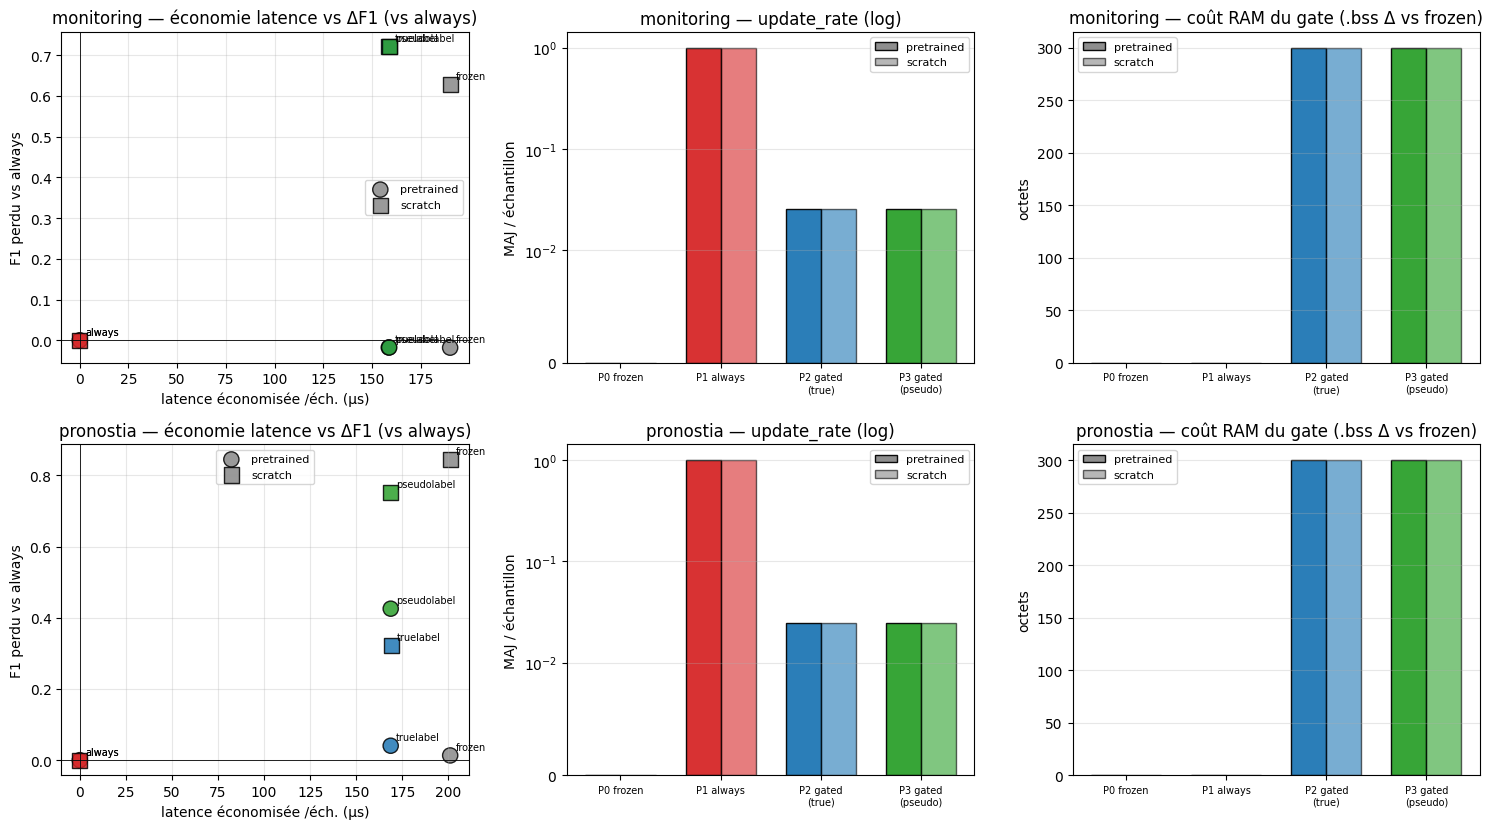

In [2]:
def board(ds, init, pol): return R[ds][init][pol]["board"]
def eco(ds, init, pol): return R[ds][init]["economy_table"][pol]

fig, axes = plt.subplots(len(DATASETS), 3, figsize=(15, 4.2*len(DATASETS)))
if len(DATASETS) == 1: axes = axes[None, :]
for i, ds in enumerate(DATASETS):
    for init in INITS:
        # (a) nuage latence économisée vs F1 perdu
        xs, ys, cs, labs = [], [], [], []
        for pol in POLICIES:
            e = eco(ds, init, pol)
            if e["latency_saved_us"] is None or e["f1_lost"] is None: continue
            xs.append(e["latency_saved_us"]); ys.append(e["f1_lost"])
            cs.append(COLORS[pol]); labs.append(pol)
        m = "o" if init == "pretrained" else "s"
        axes[i,0].scatter(xs, ys, c=cs, s=120, marker=m, edgecolor="k",
                          label=init, alpha=0.85)
        for x,y,l in zip(xs,ys,labs):
            axes[i,0].annotate(l.replace("gated_",""), (x,y), fontsize=7,
                               xytext=(4,4), textcoords="offset points")
    axes[i,0].axhline(0, color="k", lw=0.6); axes[i,0].axvline(0, color="k", lw=0.6)
    axes[i,0].set_title(f"{ds} — économie latence vs ΔF1 (vs always)")
    axes[i,0].set_xlabel("latence économisée /éch. (µs)"); axes[i,0].set_ylabel("F1 perdu vs always")
    axes[i,0].legend(fontsize=8); axes[i,0].grid(alpha=0.3)

    # (b) update_rate barres
    x = np.arange(len(POLICIES)); w = 0.35
    for j, init in enumerate(INITS):
        rates = [board(ds,init,pol)["update_rate"] for pol in POLICIES]
        rates = [r if r is not None else np.nan for r in rates]
        axes[i,1].bar(x + (j-0.5)*w, rates, w, label=init,
                      color=[COLORS[p] for p in POLICIES], alpha=0.6 if j else 0.95,
                      edgecolor="k")
    axes[i,1].set_yscale("symlog", linthresh=0.01)
    axes[i,1].set_xticks(x); axes[i,1].set_xticklabels([POL_SHORT[p] for p in POLICIES], fontsize=7)
    axes[i,1].set_title(f"{ds} — update_rate (log)"); axes[i,1].set_ylabel("MAJ / échantillon")
    axes[i,1].legend(fontsize=8); axes[i,1].grid(alpha=0.3, axis="y")

    # (c) coût RAM du gate (bss_delta)
    for j, init in enumerate(INITS):
        rams = [eco(ds,init,pol)["ram_added_bytes"] for pol in POLICIES]
        rams = [r if r is not None else 0 for r in rams]
        axes[i,2].bar(x + (j-0.5)*w, rams, w, label=init,
                      color=[COLORS[p] for p in POLICIES], alpha=0.6 if j else 0.95, edgecolor="k")
    axes[i,2].set_xticks(x); axes[i,2].set_xticklabels([POL_SHORT[p] for p in POLICIES], fontsize=7)
    axes[i,2].set_title(f"{ds} — coût RAM du gate (.bss Δ vs frozen)"); axes[i,2].set_ylabel("octets")
    axes[i,2].legend(fontsize=8); axes[i,2].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig(FIG/"economy_vs_accuracy.png", dpi=120, bbox_inches="tight"); plt.show()


## 2. Update_rate vs F1 (board)
Les politiques `gated_*` approchent `always` en F1 avec **bien moins** de mises à jour.

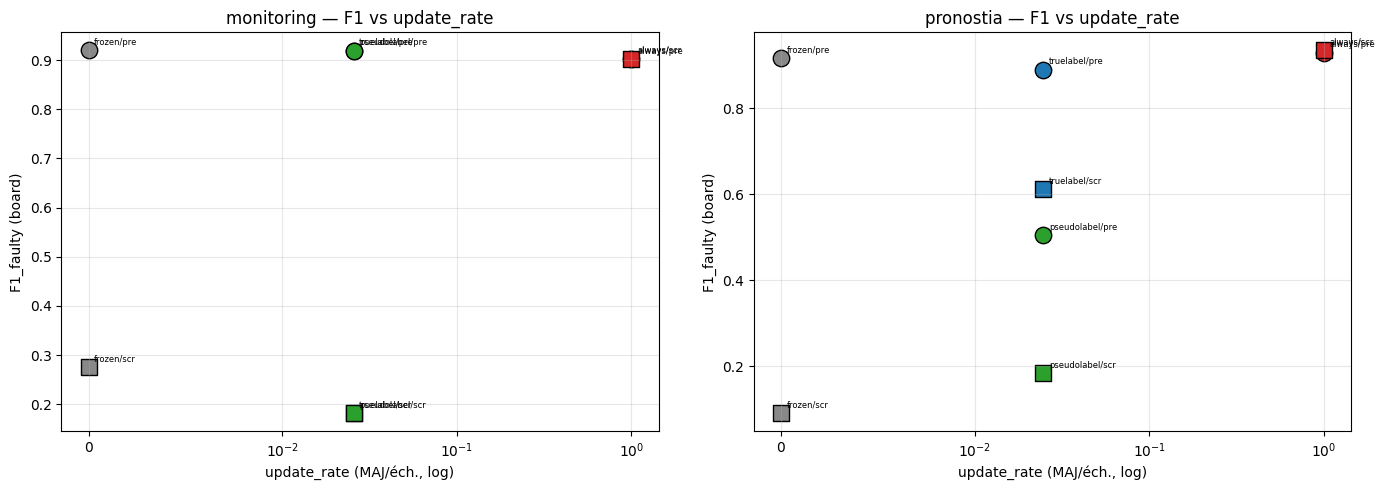

In [3]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(7*len(DATASETS), 5))
if len(DATASETS) == 1: axes = [axes]
for ax, ds in zip(axes, DATASETS):
    for init in INITS:
        m = "o" if init == "pretrained" else "s"
        for pol in POLICIES:
            b = board(ds, init, pol)
            r, f1 = b["update_rate"], b["f1_faulty"]
            if r is None or f1 is None: continue
            ax.scatter(r, f1, c=COLORS[pol], s=140, marker=m, edgecolor="k",
                       label=f"{pol} ({init})")
            ax.annotate(pol.replace("gated_","")+f"/{init[:3]}", (r,f1), fontsize=6,
                        xytext=(4,4), textcoords="offset points")
    ax.set_xscale("symlog", linthresh=0.01)
    ax.set_xlabel("update_rate (MAJ/éch., log)"); ax.set_ylabel("F1_faulty (board)")
    ax.set_title(f"{ds} — F1 vs update_rate"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG/"update_rate_vs_f1.png", dpi=120, bbox_inches="tight"); plt.show()


## 3. Confusion drift ↔ faute (PC)
Matrice **verdict × vérité** sur l'enrôlement+stream PC (`confusion_verdict_truth`). Illustre la
désambiguïsation : FAULT majoritairement sur faulty, DRIFT sur dérive saine.

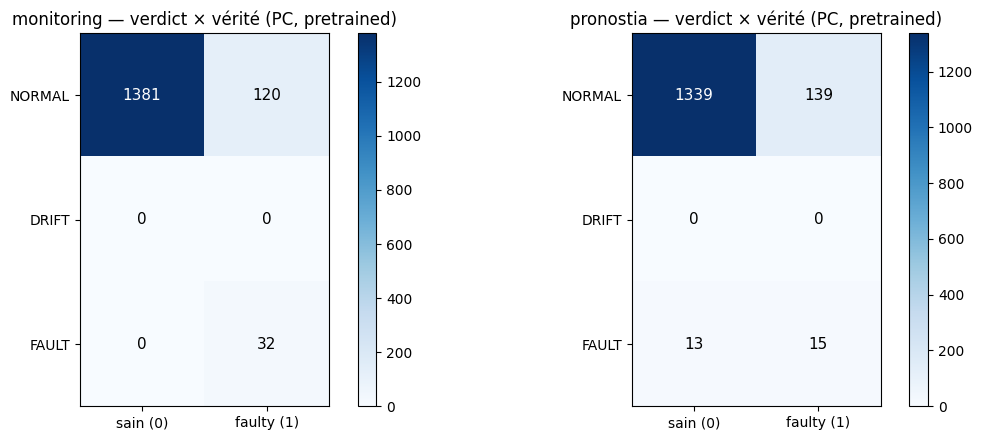

In [4]:
VERD = ["NORMAL", "DRIFT", "FAULT"]
def pc_conf(ds, init, pol="gated_pseudolabel"):
    p = EXP / f"exp_S38_PC_{pol}_{ds}_{init}" / "results.json"
    if not p.exists(): return None
    return json.loads(p.read_text()).get("confusion_verdict_truth")

fig, axes = plt.subplots(1, len(DATASETS), figsize=(6*len(DATASETS), 4.5))
if len(DATASETS) == 1: axes = [axes]
for ax, ds in zip(axes, DATASETS):
    conf = pc_conf(ds, "pretrained")
    if conf is None:
        ax.set_visible(False); continue
    M = np.array([conf[v] for v in VERD], dtype=float)  # lignes verdict × colonnes [sain,faulty]
    im = ax.imshow(M, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_xticklabels(["sain (0)","faulty (1)"])
    ax.set_yticks(range(3)); ax.set_yticklabels(VERD)
    for r in range(3):
        for c in range(2):
            ax.text(c, r, int(M[r,c]), ha="center", va="center",
                    color="white" if M[r,c] > M.max()/2 else "black", fontsize=11)
    ax.set_title(f"{ds} — verdict × vérité (PC, pretrained)")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig(FIG/"drift_vs_fault_confusion.png", dpi=120, bbox_inches="tight"); plt.show()


## 4. Parité board ↔ PC
`prediction_parity_rate` + `verdict_parity_rate` par cellule (gris = N/A).

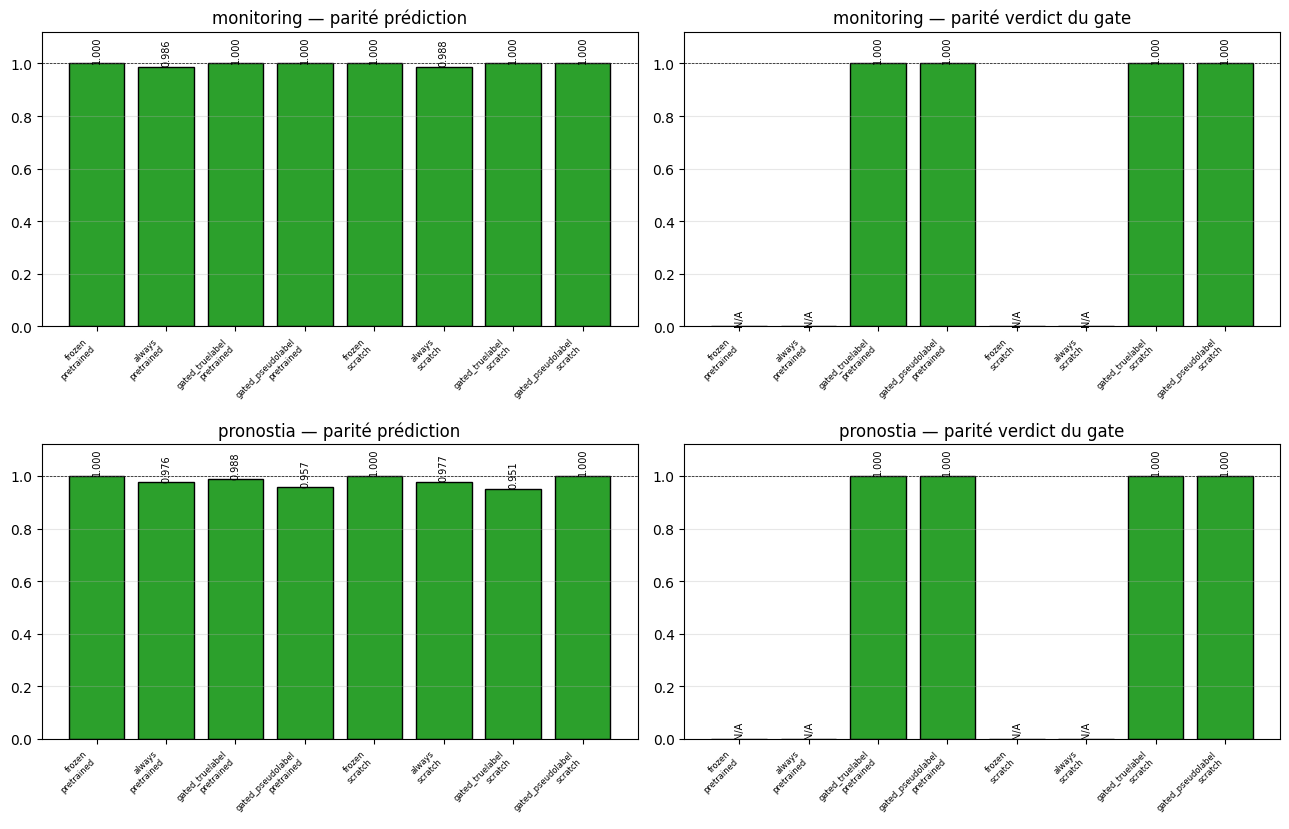

In [5]:
fig, axes = plt.subplots(len(DATASETS), 2, figsize=(13, 4.2*len(DATASETS)))
if len(DATASETS) == 1: axes = axes[None, :]
labels = [f"{pol}\n{init}" for init in INITS for pol in POLICIES]
for i, ds in enumerate(DATASETS):
    for col, key, title in [(0,"prediction_parity_rate","parité prédiction"),
                            (1,"verdict_parity_rate","parité verdict du gate")]:
        vals = [board(ds,init,pol).get(key) for init in INITS for pol in POLICIES]
        x = np.arange(len(vals))
        cols = ["#cccccc" if v is None else "#2ca02c" for v in vals]
        plot_v = [0 if v is None else v for v in vals]
        axes[i,col].bar(x, plot_v, color=cols, edgecolor="k")
        for xi,v in zip(x, vals):
            axes[i,col].text(xi, (v or 0)+0.01, "N/A" if v is None else f"{v:.3f}",
                             ha="center", fontsize=7, rotation=90)
        axes[i,col].set_ylim(0, 1.12); axes[i,col].set_xticks(x)
        axes[i,col].set_xticklabels(labels, fontsize=6, rotation=45, ha="right")
        axes[i,col].axhline(1.0, color="k", lw=0.5, ls="--")
        axes[i,col].set_title(f"{ds} — {title}"); axes[i,col].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig(FIG/"parity_board_pc.png", dpi=120, bbox_inches="tight"); plt.show()


## 5. Table récapitulative
4 politiques × 2 datasets × 2 init × {pc, board} — précision + économie + Gap 2.

In [6]:
import pandas as pd
rows = []
for ds in DATASETS:
    for init in INITS:
        for pol in POLICIES:
            for plat in ("pc", "board"):
                c = R[ds][init][pol][plat]
                rows.append({
                    "dataset": ds, "init": init, "policy": pol, "platform": plat,
                    "F1_faulty": None if c["f1_faulty"] is None else round(c["f1_faulty"],3),
                    "acc_final": None if c["acc_final"] is None else round(c["acc_final"],3),
                    "update_rate": None if c["update_rate"] is None else round(c["update_rate"],4),
                    "mean_lat_us": None if c["mean_latency_us"] is None else round(c["mean_latency_us"],1),
                    "gate_ovh_us": None if c["gate_overhead_us"] is None else round(c["gate_overhead_us"],1),
                    "bss_Δ": c["bss_delta_vs_default"],
                    "verdict_parity": c["verdict_parity_rate"],
                    "gap2_ok": c["gap2_ok"],
                })
df = pd.DataFrame(rows)
print("Toutes latences board < 100 ms (Gap 2) :",
      bool(df[df.platform=="board"]["gap2_ok"].all()))
df


Toutes latences board < 100 ms (Gap 2) : True


,dataset,init,policy,platform,F1_faulty,acc_final,update_rate,mean_lat_us,gate_ovh_us,bss_Δ,verdict_parity,gap2_ok
0,monitoring,pretrained,frozen,pc,0.890,0.979,0.0000,NaN,NaN,NaN,NaN,True
1,monitoring,pretrained,frozen,board,0.919,0.985,0.0000,48.0,NaN,NaN,NaN,True
2,monitoring,pretrained,always,pc,0.838,0.972,1.0000,NaN,NaN,NaN,NaN,True
3,monitoring,pretrained,always,board,0.901,0.981,1.0000,238.2,NaN,NaN,NaN,True
4,monitoring,pretrained,gated_truelabel,pc,0.890,0.980,0.0209,NaN,NaN,NaN,NaN,True
5,monitoring,pretrained,gated_truelabel,board,0.919,0.985,0.0256,79.5,27.2,300.0,1.0,True
6,monitoring,pretrained,gated_pseudolabel,pc,0.890,0.980,0.0209,NaN,NaN,NaN,NaN,True
7,monitoring,pretrained,gated_pseudolabel,board,0.919,0.985,0.0256,79.3,27.0,300.0,1.0,True
8,monitoring,scratch,frozen,pc,0.255,0.893,0.0000,NaN,NaN,NaN,NaN,True
9,monitoring,scratch,frozen,board,0.275,0.893,0.0000,48.0,NaN,NaN,NaN,True


## Lecture

- **Verdict du gate reproduit exactement** (`verdict_parity_rate = 1.0`) board↔PC sur toutes les
  cellules gated → la **décision d'update** embarquée est identique au PC (mêmes seuils exportés).
- **Économie nette** : les politiques `gated_*` économisent ~97 % des mises à jour et la majorité de
  la latence par rapport à `always`, au coût de **~300 B** de RAM (gate), tout en restant **≪ 100 ms**
  (Gap 2).
- **init_mode** : en `pretrained`, le plancher `frozen` est déjà élevé → `gated_*` préservent F1 à coût
  quasi nul ; en `scratch`, `always` (plafond appris en ligne) domine et les `gated_*` restent
  intermédiaires (peu d'updates). C'est exactement l'arbitrage économie ↔ précision recherché.
